In [1]:
import numpy as np
from ScanImageTiffReader import ScanImageTiffReader
import napari
import pickle

In [2]:
from skimage import data
from scipy import stats
from scipy import signal
from tifffile import tifffile
from os.path import sep
from matplotlib import pyplot as plt
import math
import matplotlib.colors as colors
import xarray as xr
import pandas as pd
import seaborn as sns
import json
import os
from scipy.ndimage import gaussian_filter1d

In [3]:
import SessionTools.two_photon as st2p
from fly2p_function_TQ.imaging_2p_preprocessing import combine_single_tiff, computeMotionShift, motionCorrection, low_pass_filter_TQ, high_pass_filter_TQ, averaging_frame, combine_single_tiff_ch1
from fly2p_function_TQ.imaging_2p_preprocessing import combine_PB_corresponding_ROI,get_raw_F,get_dff_array, normalizing_dff_array, combine_single_tiff_V2, combine_EB_corresponding_ROI,get_dff_array_running
from fly2p_function_TQ.imaging_2p_PVA_functions import PVA_radian_calcul, PVAangleToRoi, PVA_radian_to_angle, PVA_angle_to_radian, calcualteBumpAmplitude
from fly2p_function_TQ.imaging_2p_fictrac_imaging_alignment import downsample_heading_to_total_volume, offset_calculation,fictrack_signal_decoding,moving_wrapped_plot_by_offset
from fly2p_function_TQ.imaging_2p_fixed_heading_period_analysis import find_stop_period_on_heading

In [4]:
# Some key parameters for imaging analysis (for futuure should come from direct reading of metadata file)
volume_cycle = 2321
volume_time = 0.12927
volume_rate = 1/volume_time
slice_per_volume = 8
fictrack_sampling_rate = 50000

# 1 for cl, 0 for dark trial
trial_type = 0

# 1 for PB
brain_region = 0

In [5]:
green = 1
red = 0

In [6]:
time_array_imaging = np.arange(volume_cycle)/volume_rate

In [7]:
if green == 1:
    image_data_combined, tiff_file_sequence = combine_single_tiff(slice_num = slice_per_volume, cycle_num = volume_cycle, file_dir = '/home/tianhaoqiu/Desktop/TQfly831-003')
    image = image_data_combined

if red == 1:
    image_data_combined_red, tiff_file_sequence_red = combine_single_tiff_ch1(slice_num = slice_per_volume, cycle_num = volume_cycle, file_dir = '/home/tianhaoqiu/Desktop/Pilot ASAP5/TQfly142-002')
    image_red = image_data_combined_red
image.shape

(2321, 8, 215, 512)

In [8]:
if green == 1:
    imgStack = xr.DataArray(image,dims = ['volumes [s]', 'planes [µm]', 'xpix [µm]', 'ypix [µm]'])
if red == 1:
    imgStack_red = xr.DataArray(image_red,dims = ['volumes [s]', 'planes [µm]', 'xpix [µm]', 'ypix [µm]'])

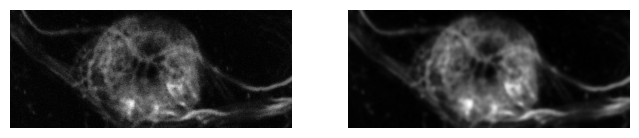

In [9]:
## Motion Correction setup
# Set reference image
stackMP = np.max(imgStack, axis=1) # max projection over volume
# Generate reference image
reference_num = np.int_(np.round(0.1 * volume_cycle))
refImg = np.mean(stackMP[0:reference_num,:,:],axis=0)

from scipy.ndimage import gaussian_filter
refImgFilt = gaussian_filter(refImg, sigma=2)

fig, axs = plt.subplots(1,2,figsize=(8,4))
axs[0].imshow(refImg,cmap='Greys_r', origin='lower'); axs[0].axis('off');
axs[1].imshow(refImgFilt,cmap='Greys_r', origin='lower'); axs[1].axis('off');

In [10]:
if red == 1:
    ## Motion Correction setup
    # Set reference image
    stackMP_red = np.max(imgStack_red, axis=1) # max projection over volume
    # Generate reference image
    reference_num = np.int_(np.round(0.1 * volume_cycle))
    refImg_red = np.mean(stackMP_red[0:reference_num,:,:],axis=0)

    from scipy.ndimage import gaussian_filter 
    refImgFilt_red = gaussian_filter(refImg_red, sigma=2)

    fig, axs = plt.subplots(1,2,figsize=(8,4))
    axs[0].imshow(refImg_red,cmap='Greys_r', origin='lower'); axs[0].axis('off');
    axs[1].imshow(refImgFilt_red,cmap='Greys_r', origin='lower'); axs[1].axis('off');

perform motion correction on a single plane/max projection


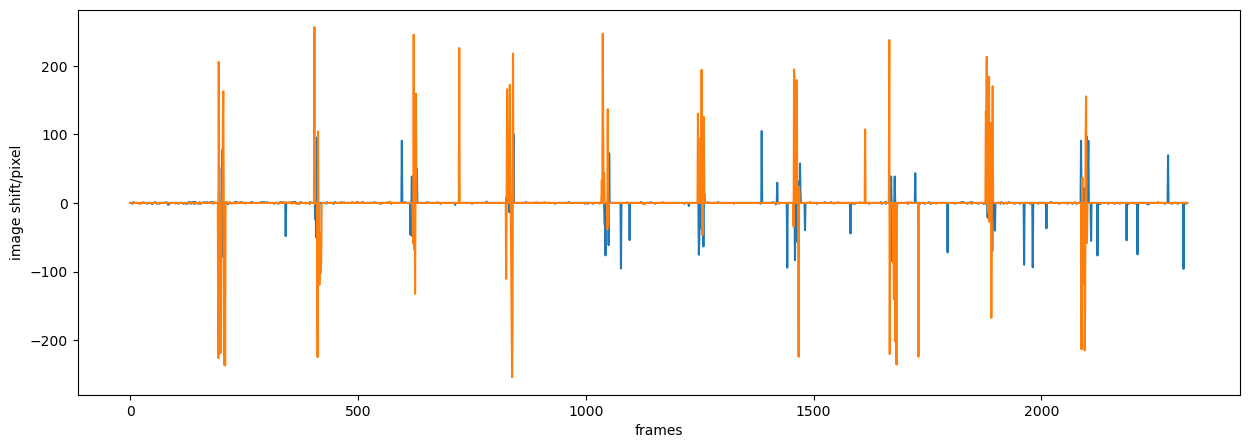

In [11]:
shift = computeMotionShift(stackMP, refImg, 10, 2, doFilter=False, stdFactor=4, showShiftFig=True)

In [12]:
if red == 1:
    shift_red = computeMotionShift(stackMP_red, refImg_red, 10, 2, doFilter=False, stdFactor=4, showShiftFig=True)

In [13]:
stack4dMC = motionCorrection(imgStack, shift)

In [14]:
if red == 1:
    stack4dMC_red = motionCorrection(imgStack_red, shift_red)

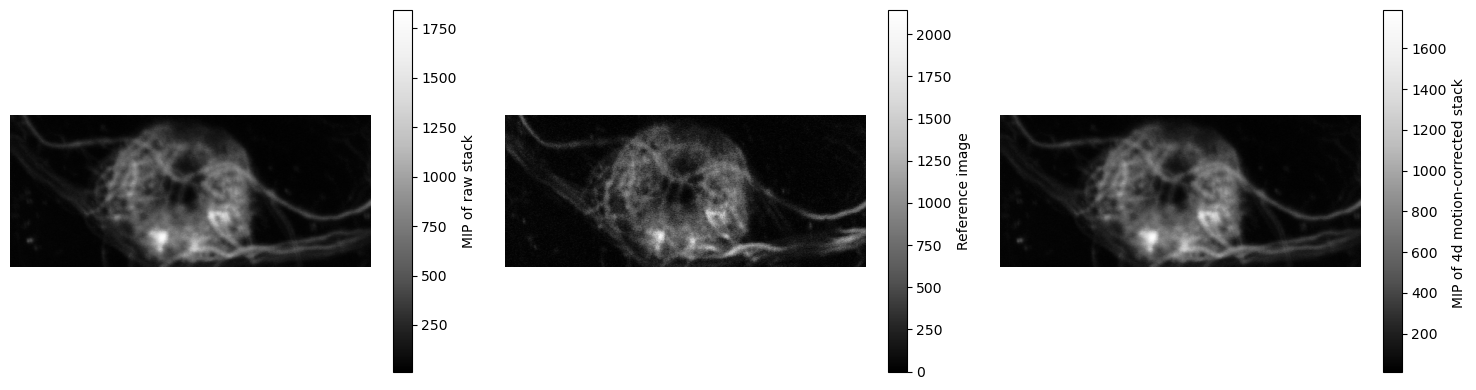

In [15]:
fig, axs = plt.subplots(1,3,figsize=(15,4))
cb = axs[0].imshow(imgStack.max(axis=1).mean(axis=0),cmap='Greys_r', origin='lower')
plt.colorbar(cb, ax=axs[0], label='MIP of raw stack')
axs[0].axis('off');
cb = axs[1].imshow(refImg,cmap='Greys_r', origin='lower')
plt.colorbar(cb, ax=axs[1], label='Reference image')
axs[1].axis('off');
cb = axs[2].imshow(stack4dMC.max(axis=1).mean(axis=0),cmap='Greys_r', origin='lower')
plt.colorbar(cb, ax=axs[2], label='MIP of 4d motion-corrected stack ')
axs[2].axis('off');
fig.tight_layout()

In [16]:
if red == 1:
    imgStack_napari_red = np.expand_dims(imgStack_red, axis =0)
if green == 1:
    #stack4dMCTEST = np.expand_dims(stack4dMC, axis =0)
    imgStack_napari = np.expand_dims(imgStack, axis =0)

In [17]:
# Use this for EB roi
if brain_region == 0:
    ebnapari = st2p.preprocessing.napari_tools.EllipsoidBodySession().new_session(imgStack_napari.mean(axis=1))
# Use this for PB roi
else:
    viewer = napari.Viewer()
    new_layer = viewer.add_image(imgStack_napari.mean(axis=1))
    #new_layer = viewer.add_image(imgStack_napari.mean(axis=1))
    #viewer.dims.ndisplay = 3

In [18]:
if brain_region == 0:
    ebnapari.make_phase_masks()

In [18]:
label = tifffile.imread("/home/tianhaoqiu/Documents/GitHub/2p_analysis/napari_roi//ROI_1_TQfly831-001.tif")
label_background = tifffile.imread("/home/tianhaoqiu/Documents/GitHub/2p_analysis/napari_roi/ROI_1_TQfly831-001_background.tif")
if red == 1:
    label_red = tifffile.imread("/home/tianhaoqiu/Documents/GitHub/2p_analysis/napari_roi/delta7_ASAP5/napari_ROI_TQfly142/ROI_1_TQfly142_002_red.tif")
#viewer.add_labels(label, name='Labels_16_Roi'

In [19]:
#Load ROI and label from napari
#napari_roi_16 = viewer.layers['Labels_16_Roi'].data
if brain_region == 0: 
    napari_roi = label    
    napari_roi_background = label_background 
else:
    #napari_roi = label[0,:,:,:]
    #Start from TQfly081, easier way to save ROI
    napari_roi = np.squeeze(label , axis=0) 
    napari_roi_background = np.squeeze(label_background , axis=0) 
    if red == 1:
        napari_roi_red = np.squeeze(label_red , axis=0) 

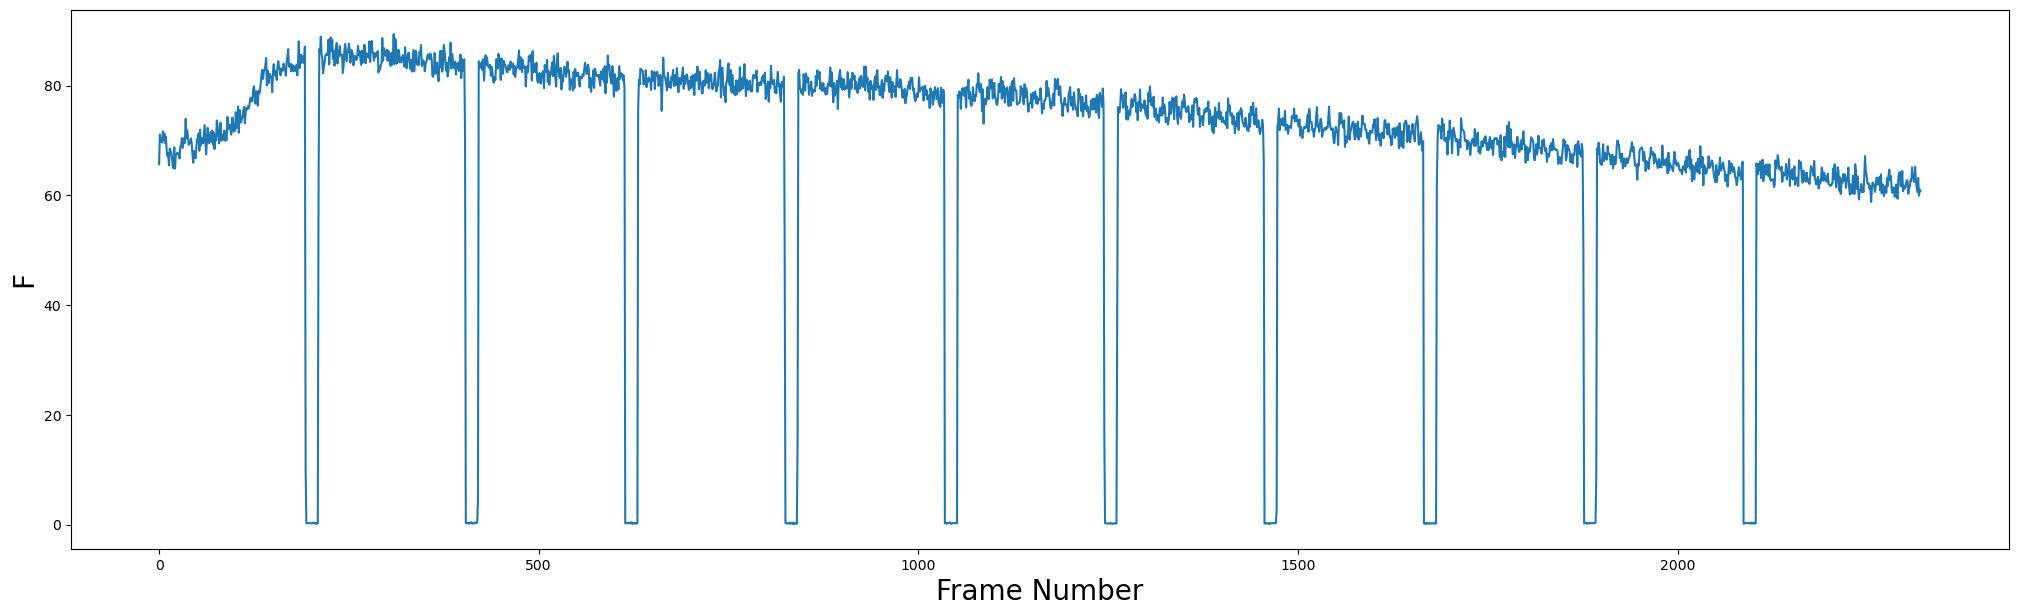

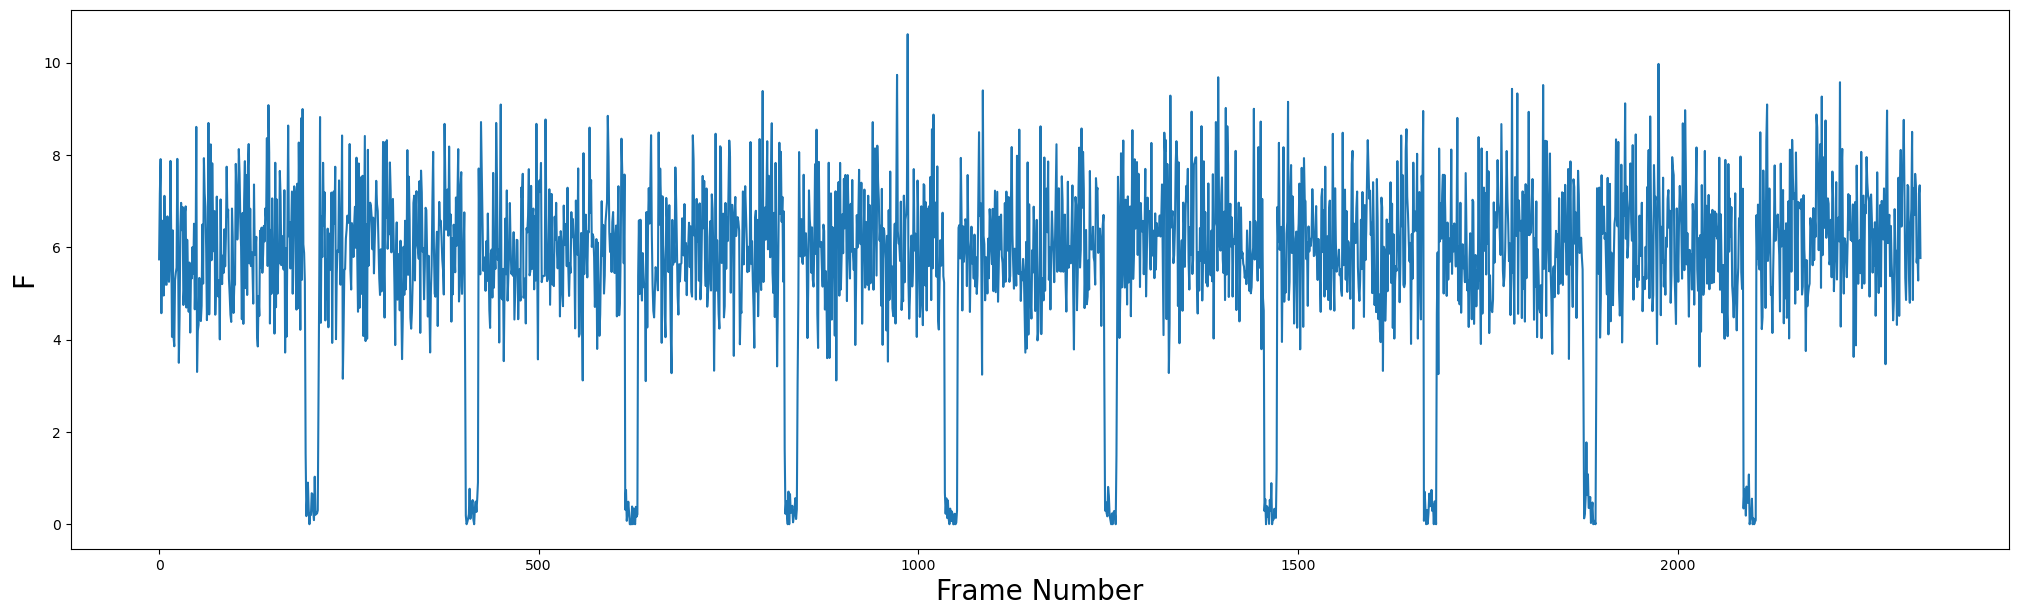

In [20]:
ROI_total = 1
F_array = get_raw_F(ROI_total, napari_roi, imgStack)
F_array_background = get_raw_F(ROI_total, napari_roi_background, imgStack)
if red == 1:
    F_array_red = get_raw_F(ROI_total, napari_roi_red, imgStack_red)

In [21]:
# Define parameters
thresholds = np.percentile(F_array, 9, axis=0)  # Compute separate threshold per ROI (3th percentile)
min_duration = 10# Minimum number of frames for a valid stimulation period
start_frame = 100  # Ignore the first 100 frames before detecting stimulation

# Step 1: Detect low-signal frames per ROI
low_signal_per_roi = F_array < thresholds  # Boolean mask: True where signal is below threshold

# Step 2: Identify frames where **any** ROI detects a stimulation period
low_signal_any = np.any(low_signal_per_roi, axis=1)  # If any ROI marks this frame, it's a stim frame

# Step 3: Find contiguous low-signal periods **starting from frame 100**
stimulation_periods = []
current_start = None

for i in range(start_frame, len(low_signal_any)):  # Start from frame 100
    if low_signal_any[i]:  # If any ROI classifies this frame as stim
        if current_start is None:
            current_start = i  # Mark the start of a stimulation period
    else:
        if current_start is not None:
            # Check if the stim period is long enough
            if i - current_start >= min_duration:
                stimulation_periods.append((current_start, i - 1))
            current_start = None  # Reset

# Handle the last stimulation period if it extends until the end
if current_start is not None and len(low_signal_any) - current_start >= min_duration:
    stimulation_periods.append((current_start, len(low_signal_any) - 1))

# Print results
print("Detected Stimulation Periods (starting from frame 100):", stimulation_periods)

Detected Stimulation Periods (starting from frame 100): [(193, 210), (404, 420), (614, 630), (824, 841), (1035, 1051), (1245, 1262), (1456, 1472), (1666, 1682), (1876, 1893), (2087, 2103)]


In [22]:
# Step 1: Create a mask for removal
frames_to_keep = np.ones(F_array.shape[0], dtype=bool)  # Keep all frames initially

for start, end in stimulation_periods:
    frames_to_keep[start:end+1] = False  # Mark stimulation frames as False (to be removed)


# Step 2: Apply mask to remove stimulation frames
F_array_stimulation_period_removed = F_array[frames_to_keep]

# Step 3: Find correct post-stimulation indices in `filtered_data`
stimulation_durations = np.zeros(len(stimulation_periods))
for i in range(len(stimulation_periods)):
    stimulation_durations[i] = stimulation_periods[i][1] - stimulation_periods[i][0] + 1

cut_indices = np.zeros(len(stimulation_periods))
for j in range(len(stimulation_periods)):
    cut_indices[j] = (stimulation_periods[j][1] + 1) - (np.sum(stimulation_durations[0:(j+1)]))
cut_indices = cut_indices.astype(int)

# Step 4: Print results
print("Original shape:", F_array.shape)
print("F_array_stimulation_period_removed :", F_array_stimulation_period_removed .shape)
print("Cut indices (in F_array_stimulation_period_removed ):", cut_indices)

Original shape: (2321, 1)
F_array_stimulation_period_removed : (2147, 1)
Cut indices (in F_array_stimulation_period_removed ): [ 193  386  579  772  965 1158 1351 1544 1737 1930]


In [23]:
# Step 1: Create a mask for removal
frames_to_keep = np.ones(F_array_background.shape[0], dtype=bool)  # Keep all frames initially

for start, end in stimulation_periods:
    frames_to_keep[start:end+1] = False  # Mark stimulation frames as False (to be removed)


# Step 2: Apply mask to remove stimulation frames
F_array_background_stimulation_period_removed = F_array_background[frames_to_keep]

# Step 3: Find correct post-stimulation indices in `filtered_data`
stimulation_durations = np.zeros(len(stimulation_periods))
for i in range(len(stimulation_periods)):
    stimulation_durations[i] = stimulation_periods[i][1] - stimulation_periods[i][0] + 1

cut_indices = np.zeros(len(stimulation_periods))
for j in range(len(stimulation_periods)):
    cut_indices[j] = (stimulation_periods[j][1] + 1) - (np.sum(stimulation_durations[0:(j+1)]))
cut_indices = cut_indices.astype(int)

# Step 4: Print results
print("Original shape:", F_array_background.shape)
print("F_array_stimulation_period_removed :", F_array_background_stimulation_period_removed.shape)
print("Cut indices (in F_array_stimulation_period_removed ):", cut_indices)

Original shape: (2321, 1)
F_array_stimulation_period_removed : (2147, 1)
Cut indices (in F_array_stimulation_period_removed ): [ 193  386  579  772  965 1158 1351 1544 1737 1930]


In [24]:
volume_cycle_new = len(F_array_stimulation_period_removed )
time_array_imaging = np.arange(volume_cycle_new)/volume_rate

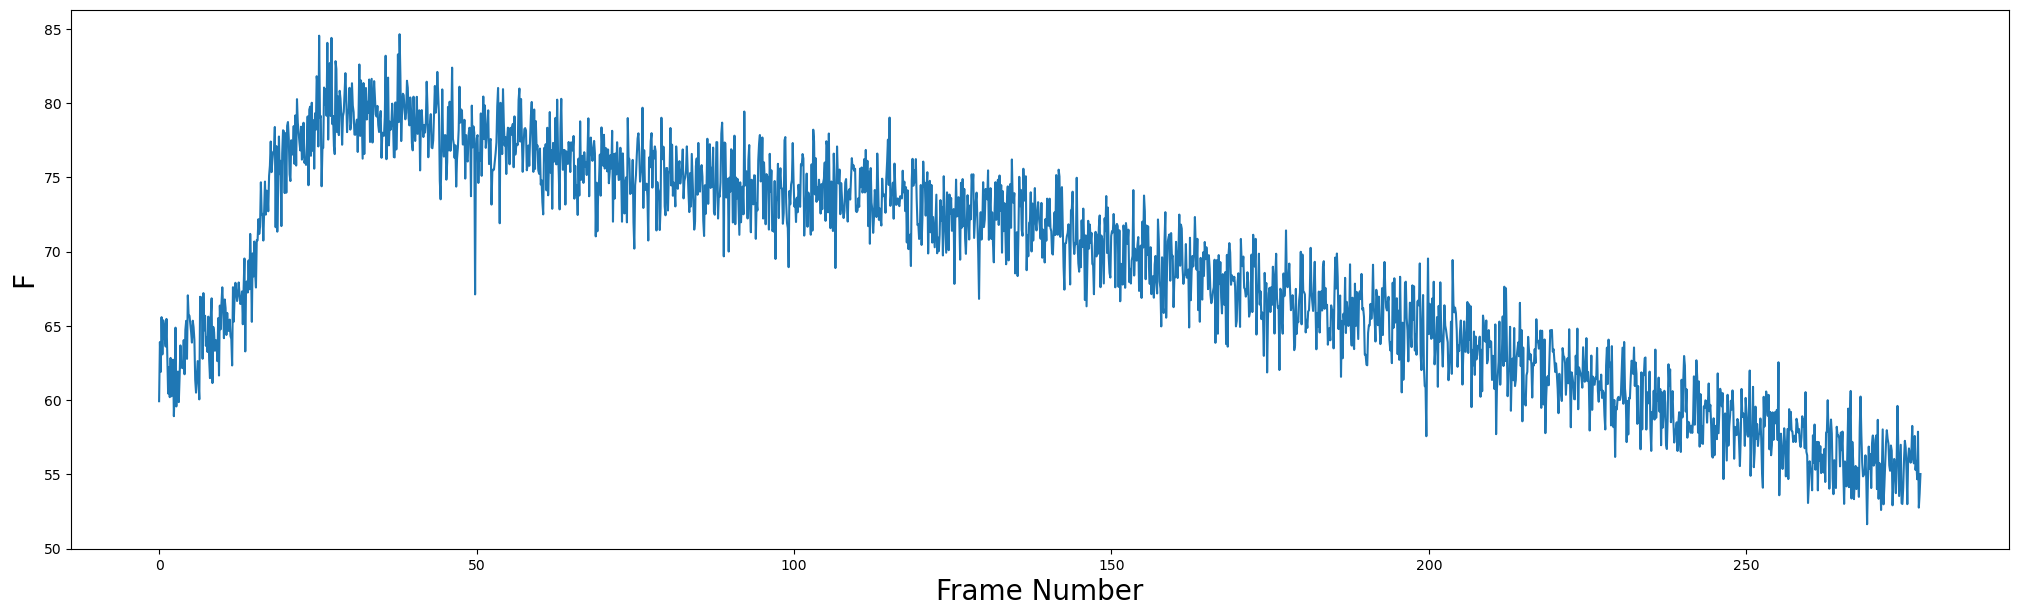

In [25]:
F_array_bg_subtracted = F_array_stimulation_period_removed - F_array_background_stimulation_period_removed
plt.figure(figsize= (25,7))
plt.plot(time_array_imaging, F_array_bg_subtracted)
plt.ylabel('F',fontsize=20)
plt.xlabel('Frame Number', fontsize=20)
plt.show()

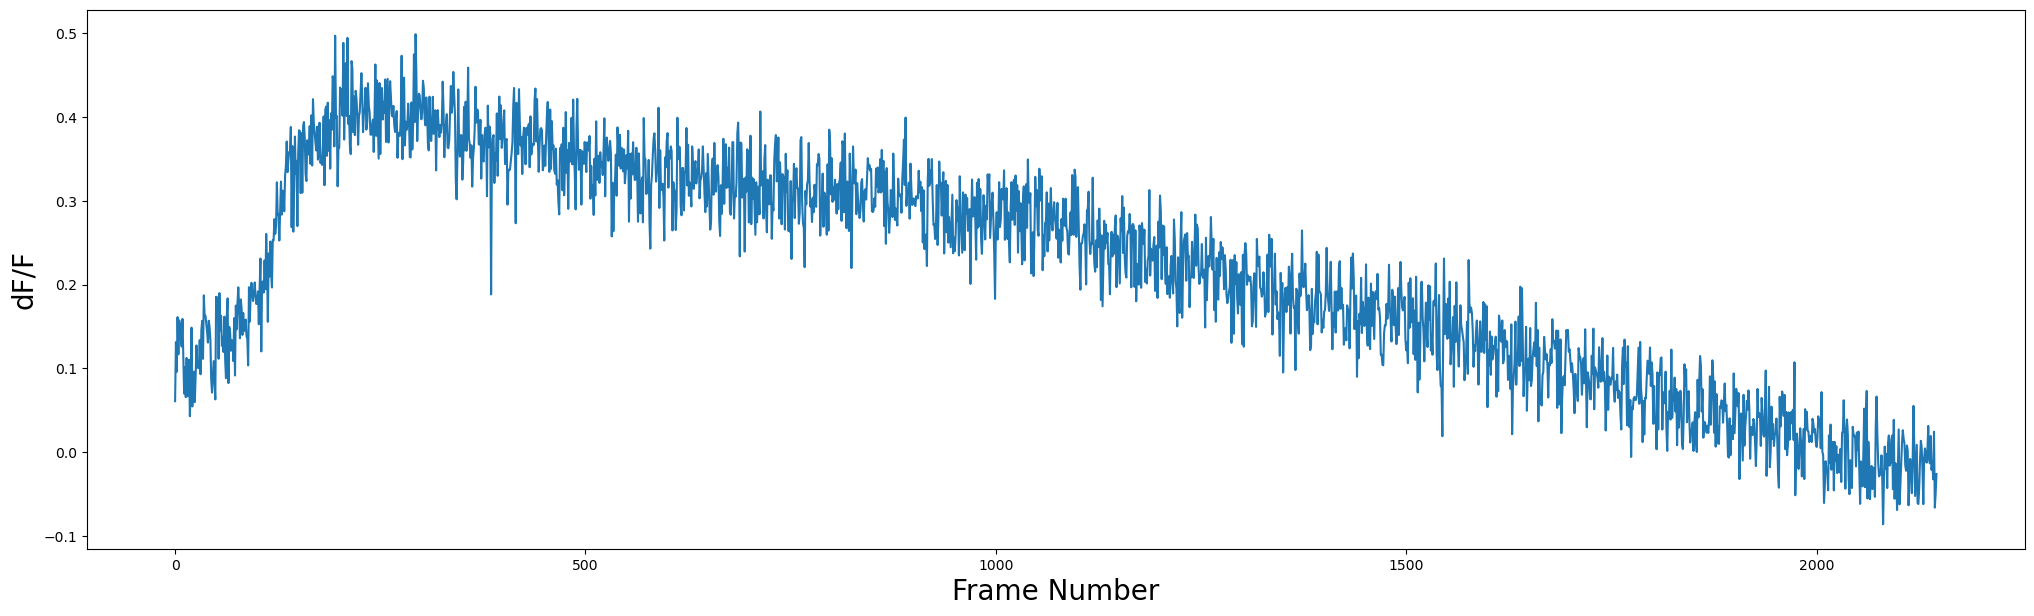

In [26]:
dF_F_array = get_dff_array(raw_F_array = F_array_bg_subtracted, ROI_num = ROI_total, F_zero_cutoff = 0.05, if_plot= 1)
if red == 1:
    dF_F_array_red = get_dff_array(raw_F_array = F_array_red, ROI_num = ROI_total, F_zero_cutoff = 0.05,if_plot= 1)

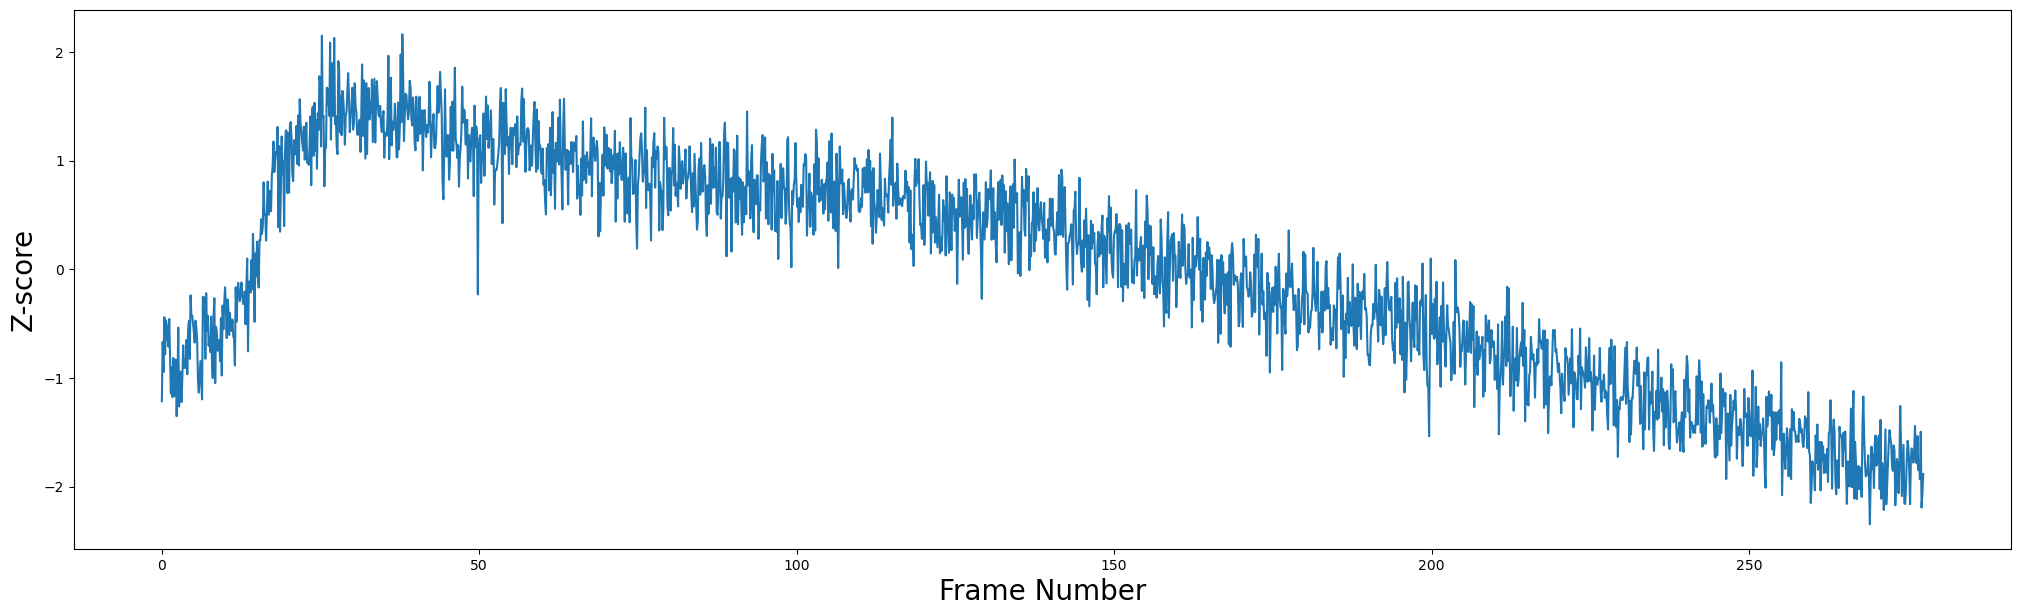

In [27]:
# Z-score: alternative way to calculate df/f
Z_score_array = np.zeros((F_array_bg_subtracted.size, ROI_total))
F_sd = np.std(F_array_bg_subtracted, axis = 0)
F_mean = np.mean(F_array_bg_subtracted, axis = 0)
for z_index in range(ROI_total):
    Z_score_array [:,z_index] = (F_array_bg_subtracted[:,z_index] - F_mean[z_index])/F_sd[z_index]

plt.figure(figsize= (25,7))
plt.plot(time_array_imaging, Z_score_array)
plt.ylabel('Z-score',fontsize=20)
plt.xlabel('Frame Number', fontsize=20)
plt.show()

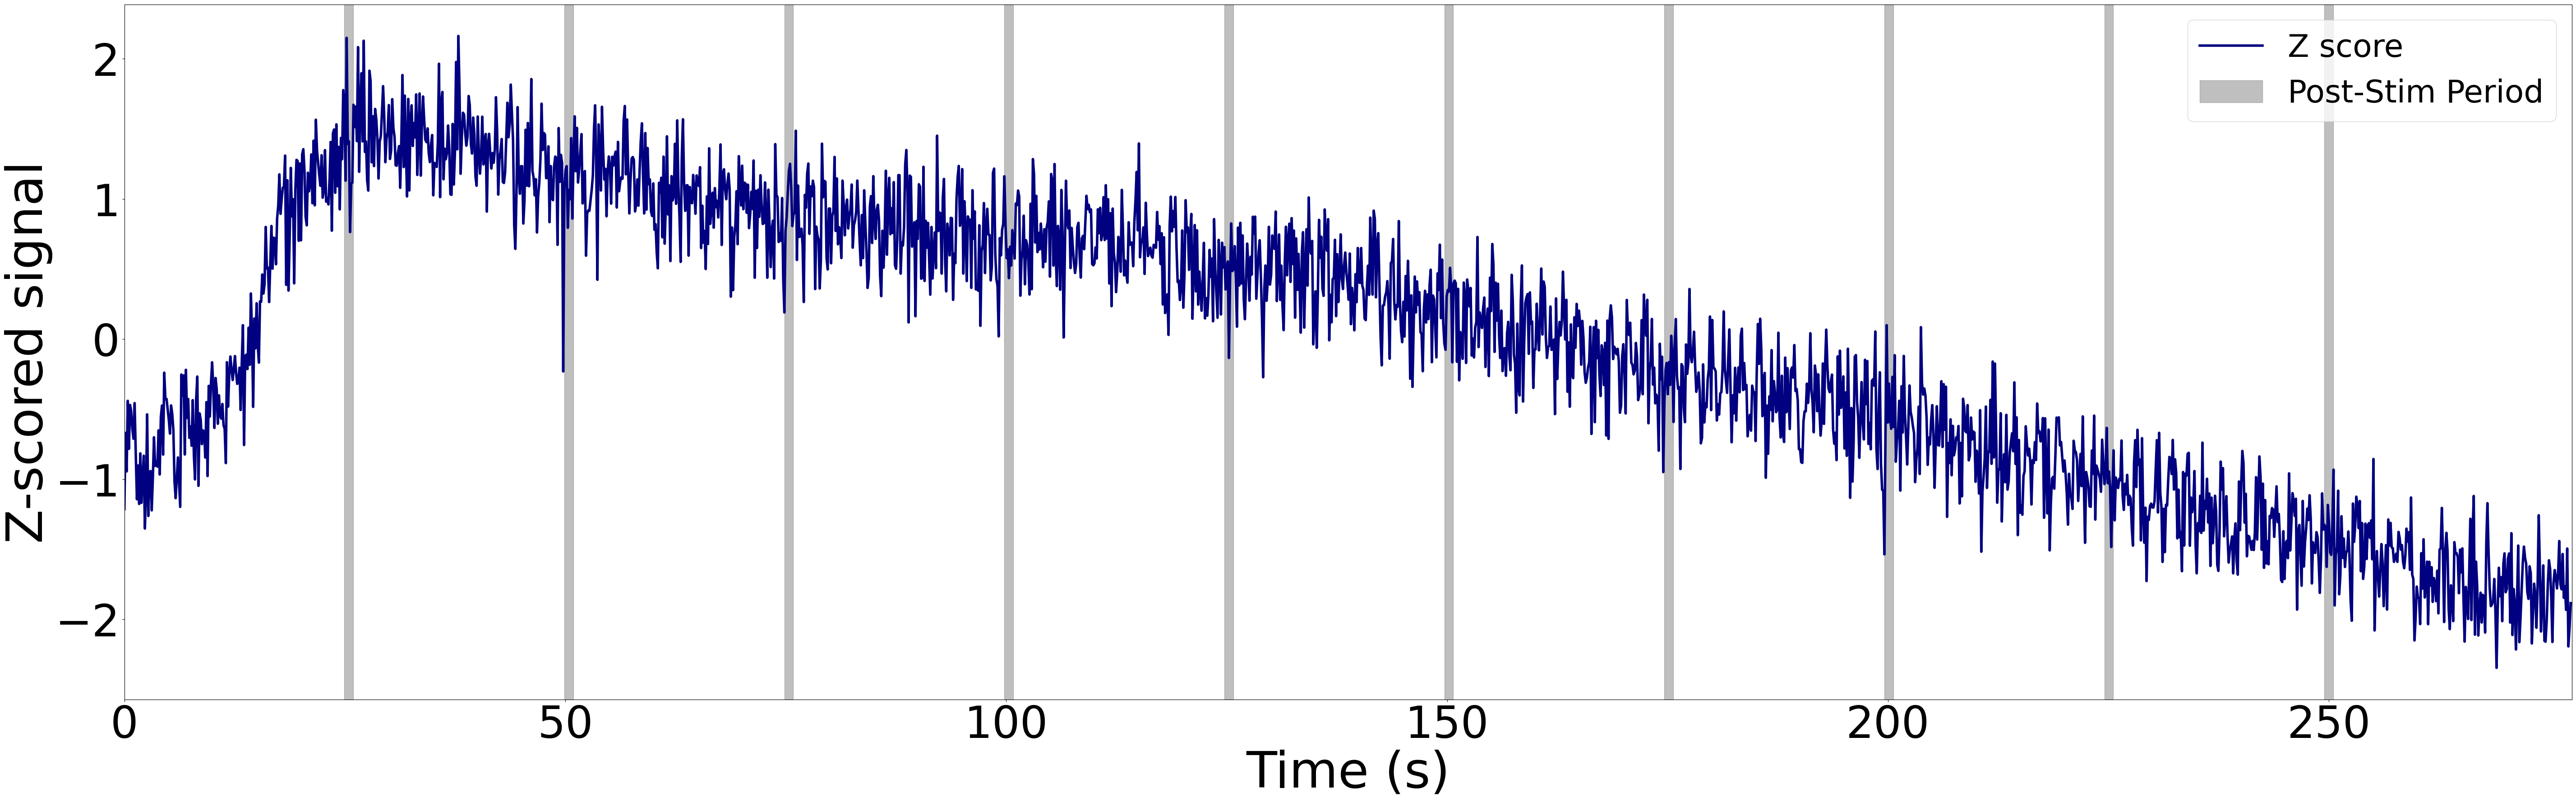

In [28]:
# Create the figure
plt.figure(figsize=(70, 20))

# Plot bump width
plt.plot(time_array_imaging, Z_score_array, linewidth=4, color='navy', label="Z score")

# Step 1: Add shaded rectangles after post-stim indices (cut_indices)
for cut in cut_indices:
    start_time = (cut) * volume_time  
    end_time = start_time + 1

    plt.axvspan(start_time, end_time, color='gray', alpha=0.5, label="Post-Stim Period" if cut == cut_indices[0] else "")

# Labels and axes formatting
plt.xlabel('Time (s)', fontsize=80)
plt.ylabel('Z-scored signal', fontsize=80)
plt.xticks(fontsize=70)
plt.yticks(fontsize=70)
plt.xlim(0, volume_cycle_new * volume_time)
plt.legend(fontsize=50)
plt.show()


In [29]:
import numpy as np

def compute_sta_around_cuts(
    signal,                # 1D array over time (or 2D T×R if you pass per-ROI; we'll reduce to amplitude)
    cut_indices,           # iterable of integer frame indices for the *cut* (we align to cut+1 like your span)
    volume_time,           # seconds per frame
    pre_s=1.0,             # window before (s)
    post_s=1.0,            # window after (s)
    align_to_next=True,    # True -> center at cut+1 (matches start_time=(cut+1)*volume_time in your code)
    baseline=None          # None | 'pre-sub' (subtract mean of pre window) | 'pre-div' (divide by |pre| mean)
):
    """
    Returns: dict with keys 'time', 'sta_mean', 'sta_sem', 'n_trials', 'epochs'
    """
    sig = np.asarray(signal)

    # If a 2D T×R array was given, convert to a single amplitude trace (range across ROIs).
    if sig.ndim == 2:
        sig = np.ptp(sig, axis=1)  # peak-to-peak across ROIs per frame

    sig = sig.astype(float).ravel()
    T = sig.size
    fps = 1.0 / float(volume_time)

    pre_f  = int(round(pre_s  * fps))
    post_f = int(round(post_s * fps))
    offsets = np.arange(-pre_f, post_f + 1, dtype=int)   # relative indices; includes time 0
    t_rel = offsets * volume_time

    epochs = []
    for cut in cut_indices:
        center = cut + 1 if align_to_next else cut
        idx = center + offsets
        if idx.min() < 0 or idx.max() >= T:
            # skip if the window would run off the trace
            continue

        seg = sig[idx].copy()
        if baseline == 'pre-sub' and pre_f > 0:
            seg -= np.nanmean(seg[:pre_f])
        elif baseline == 'pre-div' and pre_f > 0:
            denom = np.nanmean(np.abs(seg[:pre_f]))
            if denom != 0 and np.isfinite(denom):
                seg = seg / denom
            else:
                seg[:] = np.nan
        epochs.append(seg)

    if not epochs:
        raise ValueError("No epochs fell fully inside the trace for the requested window.")

    epochs = np.vstack(epochs)  # shape: n_trials × n_timepoints
    sta_mean = np.nanmean(epochs, axis=0)
    sta_sem  = np.nanstd(epochs, axis=0, ddof=1) / np.sqrt(epochs.shape[0])

    return {
        "time": t_rel,
        "sta_mean": sta_mean,
        "sta_sem": sta_sem,
        "n_trials": epochs.shape[0],
        "epochs": epochs,
    }


In [30]:
import matplotlib.pyplot as plt
import numpy as np

def plot_sta_simple(result, title="Stimulus-triggered average response", ylabel="Z score"):
    t = result["time"]
    m = result["sta_mean"]
    s = result["sta_sem"]
    n = result["n_trials"]

    plt.figure(figsize=(10, 6))
    plt.plot(t, m, linewidth=3, color='navy', label=f"Across-trial mean (n={n})")
    if np.isfinite(s).any():
        plt.fill_between(t, m - s, m + s, color='navy', alpha=0.25, label="SEM")
    plt.axvline(0, linestyle="--", color='k', alpha=0.8, label="cut (t=0)")
    plt.xlabel("Time relative to cut (s)")
    plt.ylim(-5,1.5)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


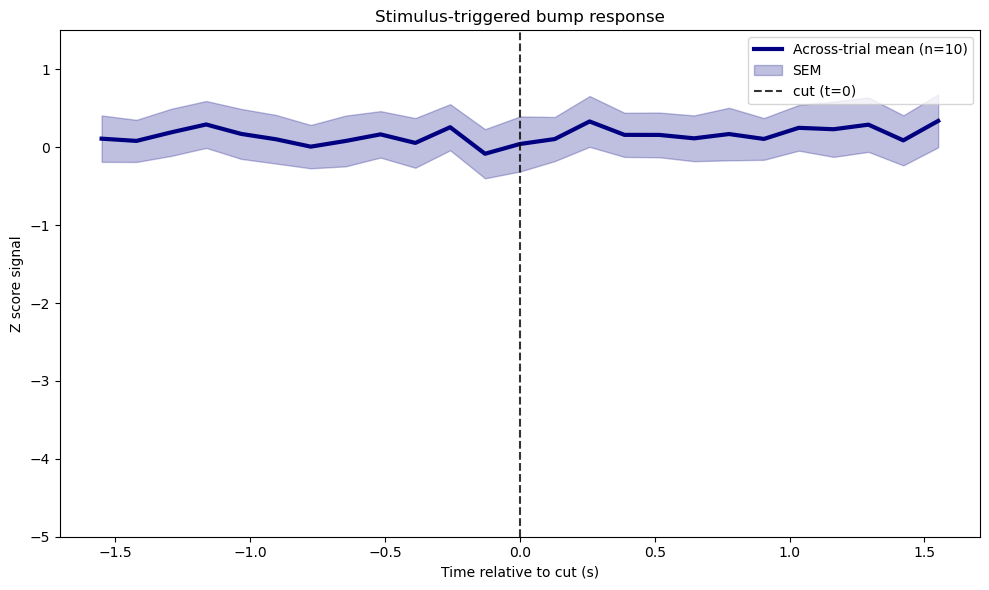

In [31]:
# Z_score_array: your 1D trace already plotted above
# cut_indices: the same indices you used for the shaded spans
# volume_time: seconds per frame (same you used earlier)
cuts_m1 = np.asarray(cut_indices, int) -1  # center = cut-1


sta = compute_sta_around_cuts(
    signal=Z_score_array.squeeze(),
    cut_indices=cuts_m1,
    volume_time=volume_time,
    pre_s=1.5,
    post_s=1.5,
    align_to_next= True,   # aligns to (cut-1), matching your shading
    baseline='None'       # or 'pre-sub' / 'pre-div' if you want baseline handling
)

plot_sta_simple(sta, title="Stimulus-triggered bump response", ylabel="Z score signal")


In [35]:
data_output = pd.DataFrame()
data_output['Time_Stamp'] = time_array_imaging
data_output['F_bg_subtracted'] = F_array_bg_subtracted[:,0]
data_output['F_data_background'] = F_array_background_stimulation_period_removed[:,0]
data_output['Raw_F_data'] = F_array_stimulation_period_removed [:,0]
data_output['Z_score_data'] = Z_score_array[:,0]
data_output['dFF_data'] = dF_F_array[:,0]

In [36]:
# Define file paths
output_file = "/home/tianhaoqiu/Documents/GitHub/2p_analysis/preprocessing_output/normalized/ExR6/ExR6_syt7f_ExR2_lexopCsCh/no drug/TQfly825-002.npz"
tif_file_path = "/home/tianhaoqiu/Documents/GitHub/2p_analysis/napari_roi/ExR6/ExR6_syt7f_ExR2_lexopCsCh/no drug/TQfly825/ROI_1_TQfly825-002.tif"  
tif_file_path_bg =  "/home/tianhaoqiu/Documents/GitHub/2p_analysis/napari_roi/ExR6/ExR6_syt7f_ExR2_lexopCsCh/no drug/TQfly825/ROI_1_TQfly825-002_background.tif" 
# Convert Pandas DataFrame to a dictionary of NumPy arrays
data_dict = {col: data_output[col].values for col in data_output.columns}

# Add the cut_indices array
data_dict["post_stim_frame"] = np.array(cut_indices)  # Ensure it's a NumPy array

# Read the TIFF file as a NumPy array
tif_image = tifffile.imread(tif_file_path)  # Load TIFF file
tif_image_bg = tifffile.imread(tif_file_path_bg)
# Add the TIFF image to the dictionary
data_dict["ROI_1"] = tif_image  # Store the TIFF as an array in the .npz file
data_dict["ROI_1_background"] = tif_image_bg
# Save everything in a .npz file
np.savez(output_file, **data_dict)

print(f"Data and TIFF image saved successfully as {output_file}")

Data and TIFF image saved successfully as /home/tianhaoqiu/Documents/GitHub/2p_analysis/preprocessing_output/normalized/ExR6/ExR6_syt7f_ExR2_lexopCsCh/no drug/TQfly825-002.npz


In [51]:
import os
import glob


# =============================
# 2. Helpers for group loading
# =============================

def _infer_volume_time_from_timestamps(ts):
    ts = np.asarray(ts).astype(float).ravel()
    d = np.diff(ts)
    d = d[np.isfinite(d) & (d > 0)]
    if d.size == 0:
        raise ValueError("Cannot infer volume_time from Time_Stamp.")
    return float(np.median(d))

def _load_trial_from_npz(path):
    z = np.load(path, allow_pickle=True)
    sig = np.asarray(z["Z_score_data"]).ravel()
    tstamp = np.asarray(z["Time_Stamp"]).ravel()
    cuts = np.asarray(z["post_stim_frame"]).astype(int).ravel()
    volume_time = _infer_volume_time_from_timestamps(tstamp)
    return {
        "signal": sig,
        "cuts_m1": cuts - 1,
        "volume_time": volume_time,
        "trial_id": os.path.basename(path),
    }

def get_npz_paths_in_folder(folder):
    """Return sorted list of all .npz files in the given folder."""
    paths = sorted(glob.glob(os.path.join(folder, "*.npz")))
    if not paths:
        raise FileNotFoundError(f"No .npz files found in {folder}")
    return paths

# =============================
# 3. Group-level STA computation
# =============================

# ---- NEW: build one global time grid over all groups ----
def _infer_dt_from_npz(path):
    z = np.load(path, allow_pickle=True)
    ts = np.asarray(z["Time_Stamp"]).ravel().astype(float)
    d = np.diff(ts)
    d = d[np.isfinite(d) & (d > 0)]
    if d.size == 0:
        raise ValueError(f"Cannot infer dt from {path}")
    return float(np.median(d))

def build_global_time_grid(all_group_paths, pre_s, post_s):
    """
    all_group_paths: list of lists, e.g. [group_A_paths, group_B_paths, ...]
    Returns t_common with identical endpoints for everyone.
    """
    dts = []
    for paths in all_group_paths:
        for p in paths:
            dts.append(_infer_dt_from_npz(p))
    if not dts:
        raise ValueError("No trials found to infer dt.")
    dt = float(np.median(dts))  # robust step

    n_left  = int(round(pre_s  / dt))
    n_right = int(round(post_s / dt))
    t_common = np.arange(-n_left, n_right + 1, dtype=float) * dt

    # snap exact endpoints to requested seconds to avoid fp drift in labels
    if len(t_common) > 0:
        t_common[0]  = -n_left * dt
        t_common[-1] =  n_right * dt
    return t_common, dt


def compute_group_sta(
    npz_paths,
    pre_s=1.5,
    post_s=1.5,
    align_to_next=True,
    baseline=None,
    t_common=None,          # <--- NEW: pass the global grid here
    edge_policy="extend"    # "extend" (recommended) or "nan"
):
    """Compute group STA by pooling epochs from multiple trials onto t_common."""
    per_trial = []
    for p in npz_paths:
        tr = _load_trial_from_npz(p)
        res = compute_sta_around_cuts(
            signal=tr["signal"],
            cut_indices=tr["cuts_m1"],
            volume_time=tr["volume_time"],
            pre_s=pre_s,
            post_s=post_s,
            align_to_next=align_to_next,
            baseline=baseline,
        )
        per_trial.append(res)

    if t_common is None:
        # Fallback: keep old behavior (but best is to pass a global grid)
        t0 = per_trial[0]["time"]
        dt = float(np.median(np.diff(t0)))
        n_left  = int(round(pre_s  / dt))
        n_right = int(round(post_s / dt))
        t_common = np.arange(-n_left, n_right + 1, dtype=float) * dt

    all_epochs = []
    n_trials_counted = 0
    for res in per_trial:
        t = res["time"]
        E = res["epochs"]
        if (len(t) == len(t_common)) and np.allclose(t, t_common, atol=1e-9):
            E_res = E
        else:
            E_res = np.empty((E.shape[0], t_common.size), dtype=float)
            for i in range(E.shape[0]):
                y = E[i]
                valid = np.isfinite(y)
                if valid.sum() < 2:
                    E_res[i, :] = np.nan
                    continue
                if edge_policy == "extend":
                    left_val  = y[valid][0]
                    right_val = y[valid][-1]
                    E_res[i, :] = np.interp(t_common, t[valid], y[valid],
                                            left=left_val, right=right_val)
                else:  # "nan"
                    E_res[i, :] = np.interp(t_common, t[valid], y[valid],
                                            left=np.nan, right=np.nan)
        all_epochs.append(E_res)
        n_trials_counted += res["n_trials"]

    all_epochs = np.vstack(all_epochs)
    sta_mean = np.nanmean(all_epochs, axis=0)
    sta_sem  = np.nanstd(all_epochs, axis=0, ddof=1) / np.sqrt(
        np.sum(np.isfinite(all_epochs), axis=0).clip(min=1)
    )
    return {
        "time": t_common,
        "sta_mean": sta_mean,
        "sta_sem": sta_sem,
        "n_trials": n_trials_counted,
        "epochs": all_epochs,
        "n_epochs_total": all_epochs.shape[0],
    }


# =============================
# 4. Plot multiple groups
# =============================


def plot_sta_groups(group_results, labels=None, colors=None,
                    title="Stimulus-triggered bump response (group comparison)",
                    ylabel="Z score"):
    if labels is None:
        labels = [f"Group {i+1}" for i in range(len(group_results))]
    if colors is None:
        colors = ["navy", "crimson", "seagreen", "darkorange"][:len(group_results)]

    plt.figure(figsize=(10, 6))
    for res, lab, col in zip(group_results, labels, colors):
        t, m, s, n = res["time"], res["sta_mean"], res["sta_sem"], res["n_trials"]
        plt.plot(t, m, linewidth=3, color=col, label=f"{lab} (n={n})")
        if np.isfinite(s).any():
            plt.fill_between(t, m - s, m + s, color=col, alpha=0.25)

    plt.axvline(0, linestyle="--", color="k", alpha=0.8, label="cut (t=0)")
    plt.xlabel("Post_stimulation period (s)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()





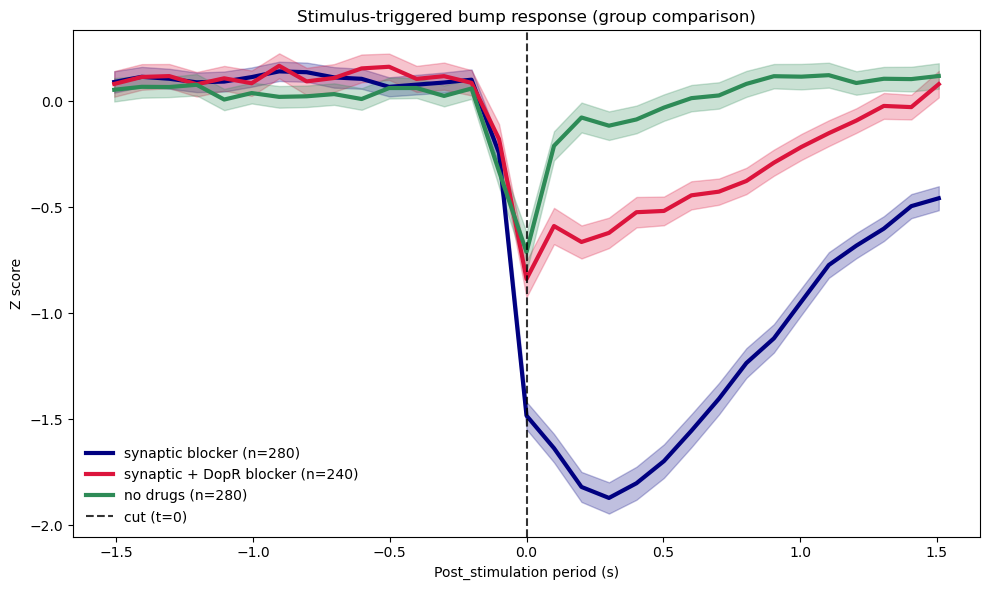

In [52]:
# =============================
# 5. Example usage
# =============================

if __name__ == "__main__":
    # Set your group folders (each folder contains multiple .npz trials)
    group_A_folder = "/home/tianhaoqiu/Documents/GitHub/2p_analysis/preprocessing_output/normalized/ExR6/ExR6_syt7f_ExR2_lexopCsCh/with synaptic blocker"
    group_B_folder = "/home/tianhaoqiu/Documents/GitHub/2p_analysis/preprocessing_output/normalized/ExR6/ExR6_syt7f_ExR2_lexopCsCh/with synaptic blocker and DopR blocker"
    # Optional third group
    group_C_folder = "/home/tianhaoqiu/Documents/GitHub/2p_analysis/preprocessing_output/normalized/ExR6/ExR6_syt7f_ExR2_lexopCsCh/no drug"

   # Collect files
    group_A_paths = get_npz_paths_in_folder(group_A_folder)
    group_B_paths = get_npz_paths_in_folder(group_B_folder)
    group_C_paths = get_npz_paths_in_folder(group_C_folder) if os.path.exists(group_C_folder) else []

    # Build one global grid from ALL groups
    all_groups = [group_A_paths, group_B_paths] + ([group_C_paths] if group_C_paths else [])
    t_common, dt_global = build_global_time_grid(all_groups, pre_s=1.5, post_s=1.5)

    # Compute group STAs ON THE SAME GRID
    gA = compute_group_sta(group_A_paths, pre_s=1.5, post_s=1.5, align_to_next=True, baseline=None, t_common=t_common)
    gB = compute_group_sta(group_B_paths, pre_s=1.5, post_s=1.5, align_to_next=True, baseline=None, t_common=t_common)
    group_results = [gA, gB]; labels = ["synaptic blocker", "synaptic + DopR blocker"]; colors = ["navy", "crimson"]

    if group_C_paths:
        gC = compute_group_sta(group_C_paths, pre_s=1.5, post_s=1.5, align_to_next=True, baseline=None, t_common=t_common)
        group_results.append(gC); labels.append("no drugs"); colors.append("seagreen")

    # Plot (all curves will now share identical x endpoints and length)
    plot_sta_groups(group_results, labels=labels, colors=colors,
                    title="Stimulus-triggered bump response (group comparison)",
                    ylabel="Z score")


In [ ]:
# Collect files
group_A_paths = get_npz_paths_in_folder(group_A_folder)
group_B_paths = get_npz_paths_in_folder(group_B_folder)
group_C_paths = get_npz_paths_in_folder(group_C_folder) if os.path.exists(group_C_folder) else []

# Build one global grid from ALL groups
all_groups = [group_A_paths, group_B_paths] + ([group_C_paths] if group_C_paths else [])
t_common, dt_global = build_global_time_grid(all_groups, pre_s=1.5, post_s=1.5)

# Compute group STAs ON THE SAME GRID
gA = compute_group_sta(group_A_paths, pre_s=1.5, post_s=1.5, align_to_next=True, baseline=None, t_common=t_common)
gB = compute_group_sta(group_B_paths, pre_s=1.5, post_s=1.5, align_to_next=True, baseline=None, t_common=t_common)
group_results = [gA, gB]; labels = ["synaptic blocker", "synaptic + DopR blocker"]; colors = ["navy", "crimson"]

if group_C_paths:
    gC = compute_group_sta(group_C_paths, pre_s=1.5, post_s=1.5, align_to_next=True, baseline=None, t_common=t_common)
    group_results.append(gC); labels.append("no drugs"); colors.append("seagreen")

# Plot (all curves will now share identical x endpoints and length)
plot_sta_groups(group_results, labels=labels, colors=colors,
                title="Stimulus-triggered bump response (group comparison)",
                ylabel="Z score")


In [41]:
# =============================
# 6. Delta metric (post - pre) and group comparison plot
# =============================

from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import re

def _fly_id_from_path(path):
    """
    Extract a fly identifier like 'TQfly790' from filenames such as 'TQfly790-001.npz'.
    Falls back to the filename stem if pattern not found.
    """
    base = os.path.basename(path)
    m = re.search(r"(TQfly\d+)", base, flags=re.IGNORECASE)
    return m.group(1) if m else os.path.splitext(base)[0]

def _bh_fdr_pvals(pvals):
    """Benjamini–Hochberg FDR correction. Returns array of q-values (same shape)."""
    p = np.asarray(pvals, float)
    n = p.size
    order = np.argsort(p)
    ranks = np.arange(1, n+1, dtype=float)
    q = np.empty_like(p)
    q[order] = np.minimum.accumulate((p[order][::-1] * n / ranks[::-1]))[::-1]
    return np.clip(q, 0, 1)

def compute_group_deltas(
    npz_paths,
    pre_window_s=1.0,        # use last 1s that ends at cut-1 frame
    post_window_s=1.0,       # use first 1s that starts at cut frame
    align_to_next=True,
    baseline=None
):
    """
    Compute per-stimulation ΔZ = mean(post) − mean(pre), where:
      pre  = last `pre_window_s` ending at the frame just BEFORE the cut,
      post = first `post_window_s` starting AT the cut frame.
    (No gap is assumed in the data.)

    Returns:
      dict with 'delta', 'pre', 'post', 'fly_ids', 'n_epochs'
    """
    all_deltas, all_pre_means, all_post_means, all_fly_ids = [], [], [], []

    # We need epochs that include at least max(pre_window_s, post_window_s) on either side.
    pre_s  = max(1e-6, pre_window_s)
    post_s = max(1e-6, post_window_s)

    for p in npz_paths:
        tr = _load_trial_from_npz(p)
        res = compute_sta_around_cuts(
            signal=tr["signal"],
            cut_indices=tr["cuts_m1"],
            volume_time=tr["volume_time"],
            pre_s=pre_s,
            post_s=post_s,
            align_to_next=align_to_next,
            baseline=baseline,
        )
        t = res["time"]       # shape (T,)
        E = res["epochs"]     # shape (n_epochs, T)

        # frame step and counts
        dt = float(np.median(np.diff(t)))
        n_pre  = int(round(pre_window_s  / dt))
        n_post = int(round(post_window_s / dt))

        # index in t that corresponds to time 0 (the cut frame)
        i0 = int(np.argmin(np.abs(t)))  # nearest to 0

        # window bounds (half-open)
        pre_lo,  pre_hi  = i0 - n_pre, i0
        post_lo, post_hi = i0, i0 + n_post

        # check bounds
        if pre_lo < 0 or post_hi > E.shape[1]:
            # If a trial's epochs are too short, skip this trial’s epochs
            # You can change to 'continue' per-epoch if you prefer partial use.
            continue

        pre_mean  = np.nanmean(E[:, pre_lo:pre_hi], axis=1)
        post_mean = np.nanmean(E[:, post_lo:post_hi], axis=1)
        delta = post_mean - pre_mean

        fly_id = _fly_id_from_path(p)
        all_deltas.append(delta)
        all_pre_means.append(pre_mean)
        all_post_means.append(post_mean)
        all_fly_ids.extend([fly_id] * delta.size)

    deltas    = np.concatenate(all_deltas, axis=0) if all_deltas else np.array([])
    pre_means = np.concatenate(all_pre_means, axis=0) if all_pre_means else np.array([])
    post_means= np.concatenate(all_post_means, axis=0) if all_post_means else np.array([])

    return {
        "delta": deltas,            # per-stimulation ΔZ
        "pre": pre_means,
        "post": post_means,
        "fly_ids": np.array(all_fly_ids),
        "n_epochs": int(deltas.size)
    }


def _per_fly_average(values, fly_ids):
    """
    Collapse per-epoch values to per-fly means.
    Returns list of fly means (one value per fly) and corresponding fly names.
    """
    values = np.asarray(values, float)
    fly_ids = np.asarray(fly_ids)
    out_vals, out_names = [], []
    for f in np.unique(fly_ids):
        m = np.nanmean(values[fly_ids == f])
        if np.isfinite(m):
            out_vals.append(m)
            out_names.append(f)
    return np.array(out_vals, float), out_names






def _bh_fdr_pvals(pvals):
    p = np.asarray(pvals, float)
    n = p.size
    order = np.argsort(p)
    ranks = np.arange(1, n+1, dtype=float)
    q = np.empty_like(p)
    q[order] = np.minimum.accumulate((p[order][::-1] * n / ranks[::-1]))[::-1]
    return np.clip(q, 0, 1)

def _star_from_p(p):
    if not np.isfinite(p): return "n.s."
    return "***" if p < 1e-3 else ("**" if p < 1e-2 else ("*" if p < 5e-2 else "n.s."))

def plot_delta_compare_groups(
    group1, group2=None, group3=None, group4=None,
    labels=("Group 1", "Group 2", "Group 3", "Group 4"),
    colors=("#1f77b4", "#d62728", "#2ca02c", "#9467bd"),
    per_fly=True,
    ylabel="ΔZ (post − pre)",
    title=None,
    jitter=0.12,
    point_size=70,
    point_alpha=0.95,
    edgewidth=0.8,
    mean_width=0.55,
    mean_lw=3,
    fontsize=12,
    ylim=(-3.8, 0.2),
    return_stats=True,
    annotate_pairs=True,
    show_pairwise_table=False,     # turn on if you want the text box
    # --- layout controls (fractions of the *data* span) ---
    kw_text_offset=0.08,           # gap above data top to place KW text
    bracket_base_offset=0.20,      # where the first bracket row starts
    bracket_row_step=0.08,         # vertical step between bracket rows
    extra_top_pad=0.06,            # extra headroom above the highest annotation
    suptitle_y=0.99                # position of the figure suptitle (0..1)
):
    groups = [g for g in (group1, group2, group3, group4) if g is not None]
    if not groups:
        print("No groups passed.")
        return None

    glabels = labels[:len(groups)]
    gcolors = colors[:len(groups)]

    # collect values
    per_group, n_units = [], []
    for G in groups:
        if per_fly:
            vals, _ = _per_fly_average(G["delta"], G["fly_ids"])
        else:
            vals = np.asarray(G["delta"], float)
            vals = vals[np.isfinite(vals)]
        per_group.append(vals)
        n_units.append(vals.size)

    # --- plot points & means ---
    fig, ax = plt.subplots(figsize=(0.6 + 1.2*len(groups), 4.8), dpi=150)
    xlocs = np.arange(1, len(groups)+1)

    data_min, data_max = np.inf, -np.inf
    for i, (x, vals, col) in enumerate(zip(xlocs, per_group, gcolors)):
        if vals.size:
            data_min = min(data_min, np.min(vals))
            data_max = max(data_max, np.max(vals))
        rng = np.random.default_rng(12_345 + i)
        xj = x + rng.uniform(-jitter, jitter, size=vals.size)

        from matplotlib.colors import to_rgb
        r,g,b = to_rgb(col); edge = (0.55*r, 0.55*g, 0.55*b)

        ax.scatter(xj, vals, s=point_size, c=col, alpha=point_alpha,
                   edgecolor=edge, linewidth=edgewidth, zorder=3)
        if vals.size:
            m = float(np.nanmean(vals))
            halfw = 0.5 * mean_width
            ax.hlines(m, x - halfw, x + halfw, color=col, linewidth=mean_lw, zorder=4)

    ax.set_xticks(xlocs)
    ax.set_xticklabels([f"{lab} (n={n})" for lab, n in zip(glabels, n_units)],
                       fontsize=fontsize-1, rotation=20, ha="right")
    ax.set_ylabel(ylabel, fontsize=fontsize)

    # initial y-lims (data-driven or provided)
    if ylim is not None:
        ax.set_ylim(*ylim)
        y0, y1 = ylim
    else:
        if not np.isfinite(data_min) or not np.isfinite(data_max):
            data_min, data_max = -1.0, 1.0
        span = (data_max - data_min) or 1.0
        y0 = data_min - 0.10*span
        y1 = data_max + 0.15*span
        ax.set_ylim(y0, y1)

    # style
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(2.0); ax.spines["bottom"].set_linewidth(2.0)
    ax.tick_params(axis='y', labelsize=fontsize-1); ax.tick_params(axis='x', width=1.6)

    # Put the title in the figure suptitle so it never collides with axis text
    if title:
        fig.suptitle(title, fontsize=fontsize+6, y=suptitle_y)

    # --- stats & annotations ---
    stats_out = None
    if return_stats:
        stats_out = {"per_group": {}, "omnibus": {}, "pairwise": []}
        for lab, vals in zip(glabels, per_group):
            v = vals[np.isfinite(vals)]
            stats_out["per_group"][lab] = {
                "n": int(v.size),
                "mean": float(np.nanmean(v)) if v.size else np.nan,
                "sem": float(np.nanstd(v, ddof=1)/np.sqrt(v.size)) if v.size > 1 else 0.0
            }

        usable = [v[np.isfinite(v)] for v in per_group if v.size]
        pairs, pair_ps, qs = [], [], []
        if len(usable) >= 2:
            H, p_kw = stats.kruskal(*usable)
            stats_out["omnibus"] = {"H": float(H), "p": float(p_kw)}

            # all pairwise
            for i in range(len(per_group)):
                for j in range(i+1, len(per_group)):
                    a, b = per_group[i], per_group[j]
                    a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
                    p = stats.mannwhitneyu(a, b, alternative="two-sided")[1] if (a.size and b.size) else np.nan
                    pair_ps.append(p); pairs.append((i, j))
            if pair_ps:
                qs = _bh_fdr_pvals(np.array(pair_ps, float))

            # compute all annotation y-positions from the original data span
            span = (y1 - y0)
            kw_y = y1 + kw_text_offset * span
            base = y1 + bracket_base_offset * span
            step = bracket_row_step * span
            top_needed = base + (max(0, len(pairs)-1)) * step + extra_top_pad * span
            # expand ylim once so nothing overlaps
            ax.set_ylim(y0, max(ax.get_ylim()[1], top_needed))

            # draw KW text
            ax.text((xlocs[0]+xlocs[-1])/2, kw_y,
                    f"Kruskal–Wallis p = {p_kw:.3g}",
                    ha="center", va="bottom", fontsize=fontsize+0)

            # optional compact table (inside axes, left-top corner)
            if show_pairwise_table and pairs:
                lines = [f"{glabels[i]} vs {glabels[j]}: p={p:.3g}, q={q:.3g} ({_star_from_p(q)})"
                         for (i,j), p, q in zip(pairs, pair_ps, qs)]
                ax.text(0.02, 0.98, "\n".join(lines), transform=ax.transAxes,
                        ha="left", va="top", fontsize=fontsize-1,
                        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.7", alpha=0.9))

            # pairwise brackets + stars
            # pairwise brackets + stars
            if annotate_pairs and pairs:
                # Adjust spacing and style for clarity
                for k, ((i, j), q) in enumerate(zip(pairs, qs)):
                    x1, x2 = xlocs[i], xlocs[j]
                    y = base + k * (step * 1.3)  # slightly increase vertical spacing between rows
                    ax.plot(
                        [x1, x1, x2, x2],
                        [y, y + 0.025 * span, y + 0.025 * span, y],
                        color="k",
                        lw=1.5,
                        clip_on=False,
                    )
                    ax.text(
                        (x1 + x2) / 2,
                        y + 0.035 * span,
                        _star_from_p(q),
                        ha="center",
                        va="bottom",
                        fontsize=fontsize + 5,      # larger font
                        fontweight="bold",          # make stars bold
                        clip_on=False,
                    )


    # leave extra room at the top for the suptitle
    fig.subplots_adjust(top=0.86)
    plt.show()
    return stats_out



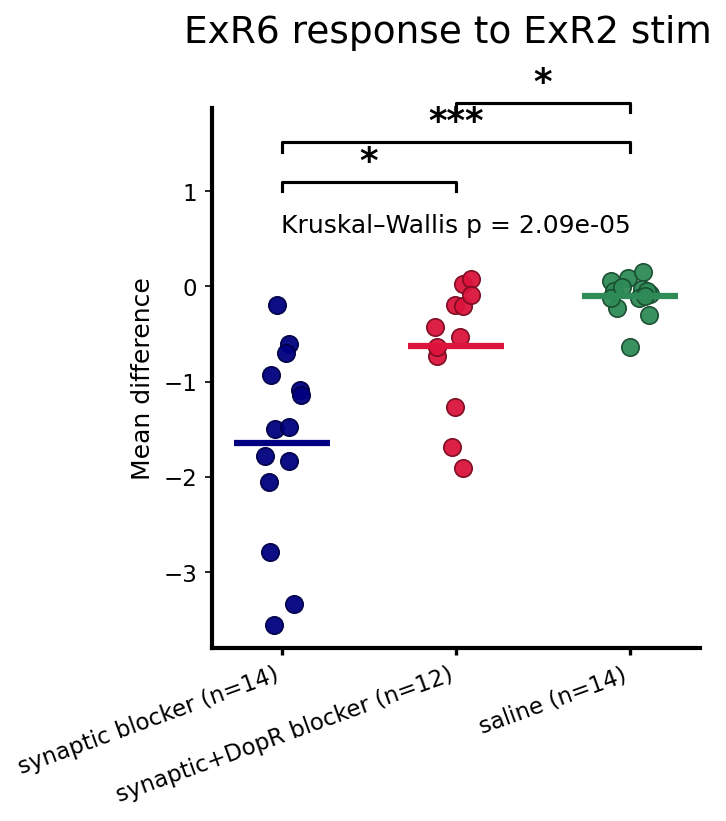

In [42]:
# Build delta datasets from your group folders
gA_npzs = get_npz_paths_in_folder(group_A_folder)
gB_npzs = get_npz_paths_in_folder(group_B_folder)
gC_npzs = get_npz_paths_in_folder(group_C_folder) if os.path.exists(group_C_folder) else []

# Per-stimulation deltas (you can tweak window sizes here)
dA = compute_group_deltas(group_A_paths, pre_window_s=1, post_window_s=1)
dB = compute_group_deltas(group_B_paths, pre_window_s=1, post_window_s=1)
dC = compute_group_deltas(group_C_paths, pre_window_s=1, post_window_s=1) if group_C_paths else None

# Plot & stats (per-fly means OR per-epoch—toggle per_fly)
stats_out = plot_delta_compare_groups(
    dA, dB, dC,
    labels=("synaptic blocker", "synaptic+DopR blocker", "saline"),
    colors=("navy", "crimson", "seagreen"),
    per_fly=True,                              # ← set False to compare per-stimulation
    ylabel="Mean difference",
    title="ExR6 response to ExR2 stim",
    return_stats=True
)

